# Gradient Boosting

#### Pourquoi choisir ce model ?

Gradient Boosting est adapté à notre problèmatique car
il construit ses arbres **en séquence** = chaque arbre corrige les
erreurs du précédent.

C'est très utile ici car certains Légendaires sont "atypiques".
"Cosmog" par exemple a des stats très faibles pour un Légendaire,
"Shaymin" ressemble beaucoup à un Pokémon normal...
Ces cas difficiles vont être progressivement corrigés au fil des arbres.

De plus, comme Random Forest, il gère naturellement les **relations non-linéaires**  et fournit
une **feature importance** pour analyser quelles stats définissent
vraiment un Légendaire.

Enfin il est robuste au déséquilibre des classes grâce au paramètre
`scale_pos_weight` qui donne plus d'importance aux Légendaires
pendant l'entraînement.

#### Différence entre Random Forest et Gradient Boosting
- **Random Forest**  : construit plein d'arbres en même temps, chacun sur un échantillon aléatoire différent, puis ils votent ensemble
- **Gradient Boosting** :  construit ses arbres un par un, chaque arbre apprend des erreurs du précédent

## 1. Imports 

In [4]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report


## 2. Récupération des données

In [5]:
from Prepro import prepare_data

# Division des données en ensembles d'entraînement et de test
# On utilise une stratification pour s'assurer que la proportion de Pokémon légendaires et normaux est similaire dans les deux ensembles
df_clean = pd.read_csv("../../data/processed/pokemon_clean.csv")
X_train, X_test, y_train, y_test, preprocessor = prepare_data(df_clean)

## 3. Entrainement des données

### 3.1 On cherche les meilleurs parametre avec ``GridSearchCV``

In [6]:
param_grid = {
    'gradientboostingclassifier__n_estimators': [100, 200, 300],
    'gradientboostingclassifier__max_depth': [3, 5, 10],
    'gradientboostingclassifier__learning_rate': [0.01, 0.1, 0.2],
    'gradientboostingclassifier__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    make_pipeline(preprocessor, GradientBoostingClassifier(random_state=42)),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleurs paramètres : {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 3, 'gradientboostingclassifier__min_samples_split': 5, 'gradientboostingclassifier__n_estimators': 100}


``learning_rate`` : C'est la vitesse à laquelle chaque arbre corrige les erreurs du précédent
- Si trop élevé (0.2) : il corrige trop vite et fait des erreurs
- Si trop faible (0.01) : il apprend très lentement mais plus précisément

Le GridSearch va trouver le meilleur équilibre automatiquement 

#### On observe que :
- ``learning_rate: 0.1`` = vitesse d'apprentissage : le modèle corrige ses erreurs à un rythme équilibré, ni trop vite ni trop lentement.
- ``max_depth: 3`` = les arbres sont peu profonds, ce qui évite l'overfitting. Le modèle préfère beaucoup de petits arbres simples plutôt que quelques grands arbres complexes.
- ``min_samples_split: 5`` = il faut au moins 5 échantillons pour diviser un nœud.
- ``n_estimators: 100`` = 100 arbres suffisent, contrairement au Random Forest qui en avait besoin de 300. C'est logique car le Gradient Boosting apprend de façon plus ciblée (chaque arbre corrige le précédent), donc il a besoin de moins d'arbres pour atteindre de bonnes performances.


### 3.2 On entraine les données

In [7]:
# Extraction des meilleurs paramètres pour les injecter dans le modèle final
best_params = {}
for k, v in grid_search.best_params_.items():
    nouvelle_cle = k.replace('gradientboostingclassifier__', '')
    best_params[nouvelle_cle] = v
# Entraînement du modèle avec les meilleurs paramètres
gb_best = make_pipeline(
    preprocessor,
    GradientBoostingClassifier(**best_params, random_state=42)
)

gb_best.fit(X_train, y_train)
y_pred = gb_best.predict(X_test)

## 4. Evaluation

### 4.1 Matrice de confusion

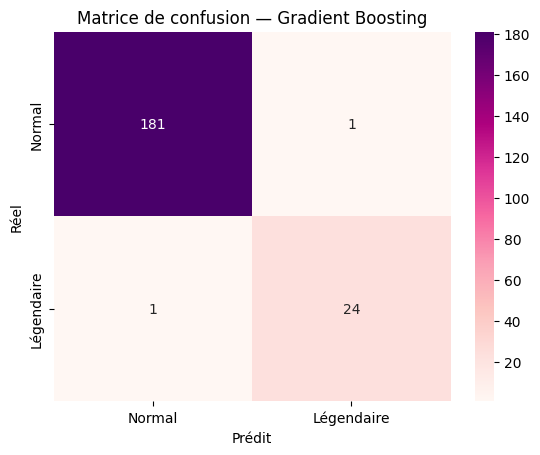

In [11]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Normal', 'Légendaire'],
            yticklabels=['Normal', 'Légendaire'])
plt.title("Matrice de confusion — Gradient Boosting")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()

On observe que :
- 181 : Pokémon normaux correctement identifiés
- 24 : Pokémon légendaires correctement identifiés 
- 1 : Un Pokémon normal classé à tort comme légendaire  (faux positif)
- 1 : Un légendaires classés à tort comme normaux  (faux négatif)

Le Gradient Boosting ne rate que 2 Pokémon au total, avec 24 légendaires sur 25 correctement identifiés (96%).

Par rapport au  Random Forest le Gradient Boosting est légèrement meilleur sur les légendaires, ce qui confirme sa force sur les cas atypiques ; il a réussi à rattraper un légendaire difficile que le Random Forest avait raté.

...

## 4.2 Rapport de classification

In [10]:
# Rapport de classification
print(classification_report(y_test, y_pred, target_names=['Normal', 'Légendaire']))
print("Meilleur score F1 (cross validation) :", grid_search.best_score_)

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       182
  Légendaire       0.96      0.96      0.96        25

    accuracy                           0.99       207
   macro avg       0.98      0.98      0.98       207
weighted avg       0.99      0.99      0.99       207

Meilleur score F1 (cross validation) : 0.9200179937022043


Ce que ça dit :

- **Accuracy = 99% :** sur 207 Pokémon de test, le modèle en rate seulement 2. *(identique au Random Forest)*
- **Precision = 96% sur les légendaires :** quand le modèle prédit un légendaires, il a raison 96% du temps. Il génère très peu de faux négatif. *(identique au Random Forest)*
- **Recall = 96% sur les légendaires :** Le modèle retrouve 96% de tous les vrais légendaires, soit 24 sur 25. Il en rate qu'un seul. *( mieux que le Random Forest (92%) )*
- **F1 = 96% sur les légendaires :** Le model est donc précis (il ne se trompe pas souvent) et complet (il en rate peu). *( mieux que le Random Forest (94%) )*

Avec 99% d'accuracy et un F1 de 96% sur les légendaires, le Gradient Boosting gère très bien le déséquilibre du dataset et identifie quasi parfaitement les Pokémon légendaires.

### 4.3 Colonnes importantes

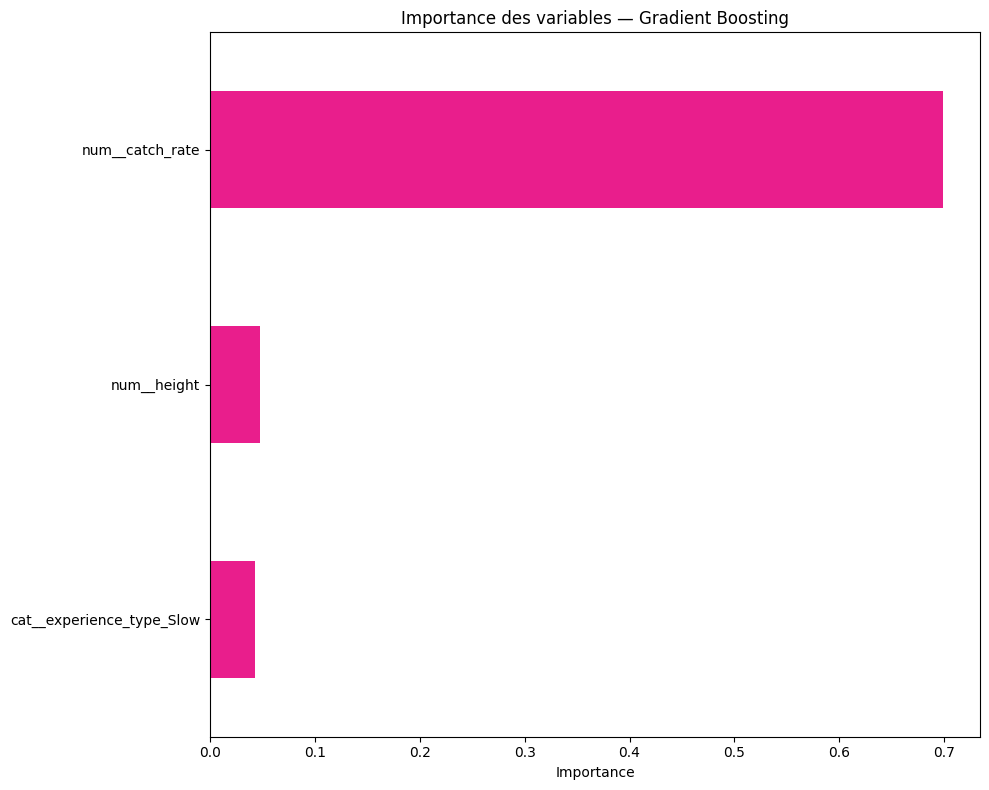

In [12]:
gb_model = gb_best.named_steps['gradientboostingclassifier']
feature_names = gb_best.named_steps['columntransformer'].get_feature_names_out()
importances = pd.Series(gb_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True).tail(3)

importances.plot(kind='barh', color='#e91e8c', figsize=(10, 8))
plt.title("Importance des variables — Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

On observe que :
- ``num__catch_rate (~0.70)`` : le taux de capture représente 70% de l'importance totale. Le modèle a découvert que c'est quasiment la seule variable dont il a besoin pour identifier un légendaire.

En comparaison les autres colonnes sont utilisées en complément mais de façon très marginale.

Contrairement au Random Forest qui répartissait l'importance sur plusieurs variables, le Gradient Boosting a identifié le catch_rate comme variable quasi suffisante à elle seule (70% d'importance), ce qui reflète une règle simple mais très efficace dans l'univers Pokémon.

Cette dépendance soulève la question du **data leakage** : la variable n'est pas une cause du statut légendaire mais une conséquence, ce qui pourrait limiter la généralisation du modèle sur de nouveaux Pokémon.

## Conclusion
Le Gradient Boosting atteint 99% d'accuracy et un F1 de 96% sur les légendaires, en s'appuyant quasi exclusivement sur le catch_rate (70% d'importance). Ce résultat confirme que le modèle a trouvé une règle simple mais extrêmement efficace : un Pokémon difficile à capturer est très probablement légendaire.

Pour aller plus loin on pourrait :
- Tester des valeurs de n_estimators plus élevées (300, 400) maintenant que la grille a été réduite pour gagner du temps

Par rapport au Random Forest, le Gradient Boosting est légèrement plus performant (F1 96% contre 94%) mais moins informatif — le Random Forest répartissait l'importance sur plusieurs variables et donnait une image plus complète de ce qui définit un légendaire.